In [ ]:
from google.colab import files
uploaded = files.upload()

Saving dataset.csv.csv to dataset.csv (1).csv


In [ ]:
import os
print(os.listdir())

['.config', 'dataset.csv (1).csv', 'dataset.csv.csv', 'sample_data']


In [ ]:
import pandas as pd
df=pd.read_csv("dataset.csv.csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [ ]:
city_counts = df['City'].value_counts()
top_city_by_count = city_counts.idxmax()
print("City with most restaurants:", top_city_by_count)
print("Count:", city_counts.max())

City with most restaurants: New Delhi
Count: 5473


In [ ]:
avg_rating_by_city = df.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False)
print(avg_rating_by_city.head(10))

City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Beechworth          4.600000
London              4.535000
Taguig City         4.525000
Secunderabad        4.500000
Lincoln             4.500000
Name: Aggregate rating, dtype: float64


In [ ]:
top_city_by_rating = avg_rating_by_city.idxmax()
print("City with highest average rating:", top_city_by_rating)
print("Rating:", avg_rating_by_city.max())

City with highest average rating: Inner City
Rating: 4.9


In [ ]:
reliable_cities = city_counts[city_counts >= 20].index
avg_rating_reliable = df[df['City'].isin(reliable_cities)].groupby('City')['Aggregate rating'].mean().sort_values(ascending=False)
print(avg_rating_reliable.head(10))

City
London            4.535
Orlando           4.475
Rest of Hawaii    4.410
Tampa Bay         4.410
Bangalore         4.375
Dubai             4.370
Chennai           4.315
Ankara            4.305
Abu Dhabi         4.300
Auckland          4.275
Name: Aggregate rating, dtype: float64


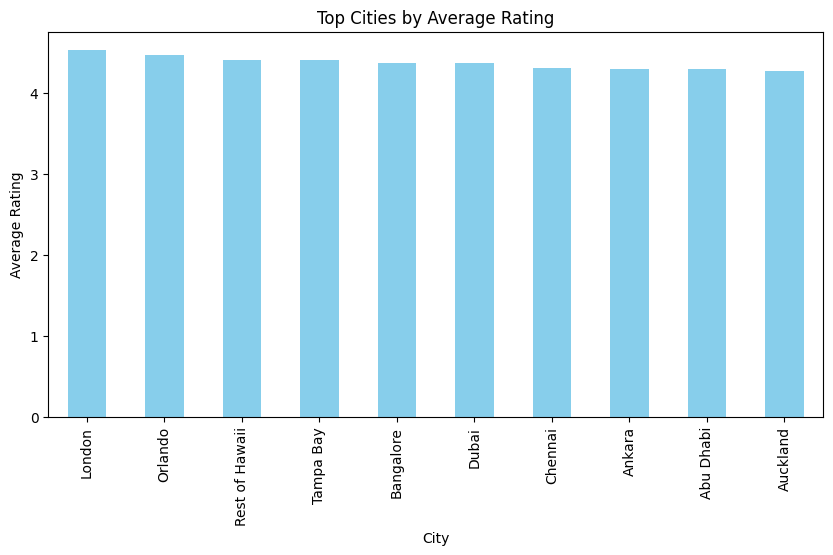

In [ ]:
import matplotlib.pyplot as plt
avg_rating_reliable.head(10).plot(kind='bar', figsize=(10,5), color='skyblue')
plt.title('Top Cities by Average Rating')
plt.ylabel('Average Rating')
plt.show()

City with most restaurants: New Delhi
City with highest average rating (raw): Inner City (only 2 restaurants — not reliable)
City with highest average rating (reliable, 20+ restaurants): Quezon City